In [ ]:
# =============================================================================
# Cell 1: Environment Setup & Data Download
# =============================================================================
# Install the required SPM package
!pip install spm1d

import urllib.request
import zipfile
import os
import glob

# The two groups we are comparing for the SPM analysis
groups = ["lannister", "stark"]
zip_dir = "kin6016/lab4"
os.makedirs(zip_dir, exist_ok=True)

print("\nStarting download process...")

for group in groups:
    zip_filename = f"spring2026_lab4_{group}.zip"
    url = f"https://raw.githubusercontent.com/plnu-biomechanics/kin6016/main/labs/{zip_filename}"
    zip_path = os.path.join(zip_dir, zip_filename)
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, "r") as zip_ref:
            zip_ref.extractall(zip_dir)
        print(f"✅ Successfully downloaded and extracted: {group.capitalize()}")
    except Exception as e:
        print(f"⚠️ Could not download {group}. Error: {e}")

print("\nCurrent files in our lab folder:")
print(os.listdir(zip_dir)[:5]) # Showing the first 5 files just to confirm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 7.6 MB/s eta 0:00:00

Starting download process...
✅ Successfully downloaded and extracted: Lannister
✅ Successfully downloaded and extracted: Stark

Current files in our lab folder:
['Stark_golfswing_03.txt', 'Lannister_golfswing_06.txt', 'Lannister_golfswing_02.txt', 'Lannister_golfswing_08.txt', 'Stark_golfswing_02.txt']


In [ ]:
# =============================================================================
# Cell 2: Data Wrangling (Parsing the Text Files)
# =============================================================================
import pandas as pd
import numpy as np
import glob
import os

# ⚠️ ACTION REQUIRED: Update 'Pelvic_Tilt_Angle' and 'Lead_Knee_Angle'
# with the exact column headers from your Visual3D .txt files!
ts_map = {
    'BACK GRF_N': 'Back_GRF',
    'LEAD GRF_N': 'Lead_GRF',
    'Back Leg Gastroc': 'Gastroc_EMG',
    'Erector Spinae': 'Erector_EMG',
    'Pelvic_Tilt_Angle': 'Kinematic_1',  # <-- Update this text
    'Lead_Knee_Angle': 'Kinematic_2'     # <-- Update this text
}

zip_dir = "kin6016/lab4"
groups = ["lannister", "stark"]

# Create empty dictionaries to hold the lists of swings
spm_arrays = {group: {var: [] for var in ts_map.values()} for group in groups}
all_files = glob.glob(os.path.join(zip_dir, "*.txt"))

print(f"Found {len(all_files)} text files. Starting to parse...")

for file in all_files:
    # Figure out if this file belongs to Lannister or Stark
    condition = 'lannister' if 'lannister' in file.lower() else 'stark' if 'stark' in file.lower() else None
    if not condition: continue

    # Read the file and clean up the column names
    df_raw = pd.read_csv(file, sep='\t', skiprows=1)
    df_raw.columns = df_raw.columns.str.strip()

    # Check which of our needed columns actually exist in this file
    valid_cols = [c for c in ts_map.keys() if c in df_raw.columns]

    # Visual3D puts the 101 frames of the swing in rows 2 to 102
    df_ts = df_raw.iloc[2:103].copy()

    for raw_col in valid_cols:
        clean_name = ts_map[raw_col]
        # Force the data into numbers, fill weird gaps with 0
        data = pd.to_numeric(df_ts[raw_col], errors='coerce').fillna(0).values

        # Convert EMG to %MVC (based on your professor's logic)
        if 'EMG' in clean_name:
            data = data * 100

        spm_arrays[condition][clean_name].append(data)

# Convert all those lists into the J x Q Matrices required for SPM
for group in groups:
    for var in ts_map.values():
        if len(spm_arrays[group][var]) > 0:
            spm_arrays[group][var] = np.array(spm_arrays[group][var])

print("\n✅ Data Wrangling Complete! All files parsed into J x Q arrays.")

# Quick test to prove it worked
test_group = 'lannister'
if len(spm_arrays[test_group]['Lead_GRF']) > 0:
    print(f"Shape of {test_group.capitalize()} Lead GRF array: {spm_arrays[test_group]['Lead_GRF'].shape}")
else:
    print("⚠️ No Lead GRF data found for Lannister. Check your column names.")

Found 20 text files. Starting to parse...

✅ Data Wrangling Complete! All files parsed into J x Q arrays.
Shape of Lannister Lead GRF array: (10, 101)


In [ ]:
# =============================================================================
# Cell 3: The 1D Statistical Mapping (SPM) Engine (UPDATED WITH VARIANCE FIX)
# =============================================================================
import spm1d
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.simplefilter(action='ignore', category=RuntimeWarning)

def plot_spm_comparison(ax, Y_lannister, Y_stark, title, y_label):
    # Failsafe if data is missing entirely
    if len(Y_lannister) == 0 or len(Y_stark) == 0:
        ax.set_title(f"{title} (Data Missing)", fontsize=10)
        return

    # THE FIX: Add microscopic noise to flatlines to prevent SPM from crashing
    Y1 = Y_lannister.copy().astype(float)
    Y2 = Y_stark.copy().astype(float)
    for i in range(Y1.shape[1]):
        if np.var(Y1[:, i]) < 1e-12:
            Y1[:, i] += np.random.rand(Y1.shape[0]) * 1e-6
        if np.var(Y2[:, i]) < 1e-12:
            Y2[:, i] += np.random.rand(Y2.shape[0]) * 1e-6

    try:
        # 1. Plot Mean and SD bands
        spm1d.plot.plot_mean_sd(Y1, linecolor='blue', facecolor='blue', alpha=0.3, ax=ax, label='Lannister')
        spm1d.plot.plot_mean_sd(Y2, linecolor='red', facecolor='red', alpha=0.3, ax=ax, label='Stark', linestyle='--')

        # 2. Run the SPM 1D T-Test on the cleaned arrays
        t_stat = spm1d.stats.ttest2(Y1, Y2, equal_var=False)
        t_inf = t_stat.inference(0.05, two_tailed=True, interp=True)

        # 3. Shade the significant regions
        for cluster in t_inf.clusters:
            start, end = cluster.endpoints
            ax.axvspan(start, end, color='grey', alpha=0.4)

    except Exception as e:
        ax.text(50, 0, f"Math Error: {e}", ha='center', color='red', fontsize=8)

    # 4. Formatting
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("% of Golf Swing", fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_xlim(0, 100)
    ax.legend(loc='upper right', fontsize=8, frameon=False)

print("✅ Cell 3 Updated: Variance fix applied.")

✅ Cell 3 Updated: Variance fix applied.


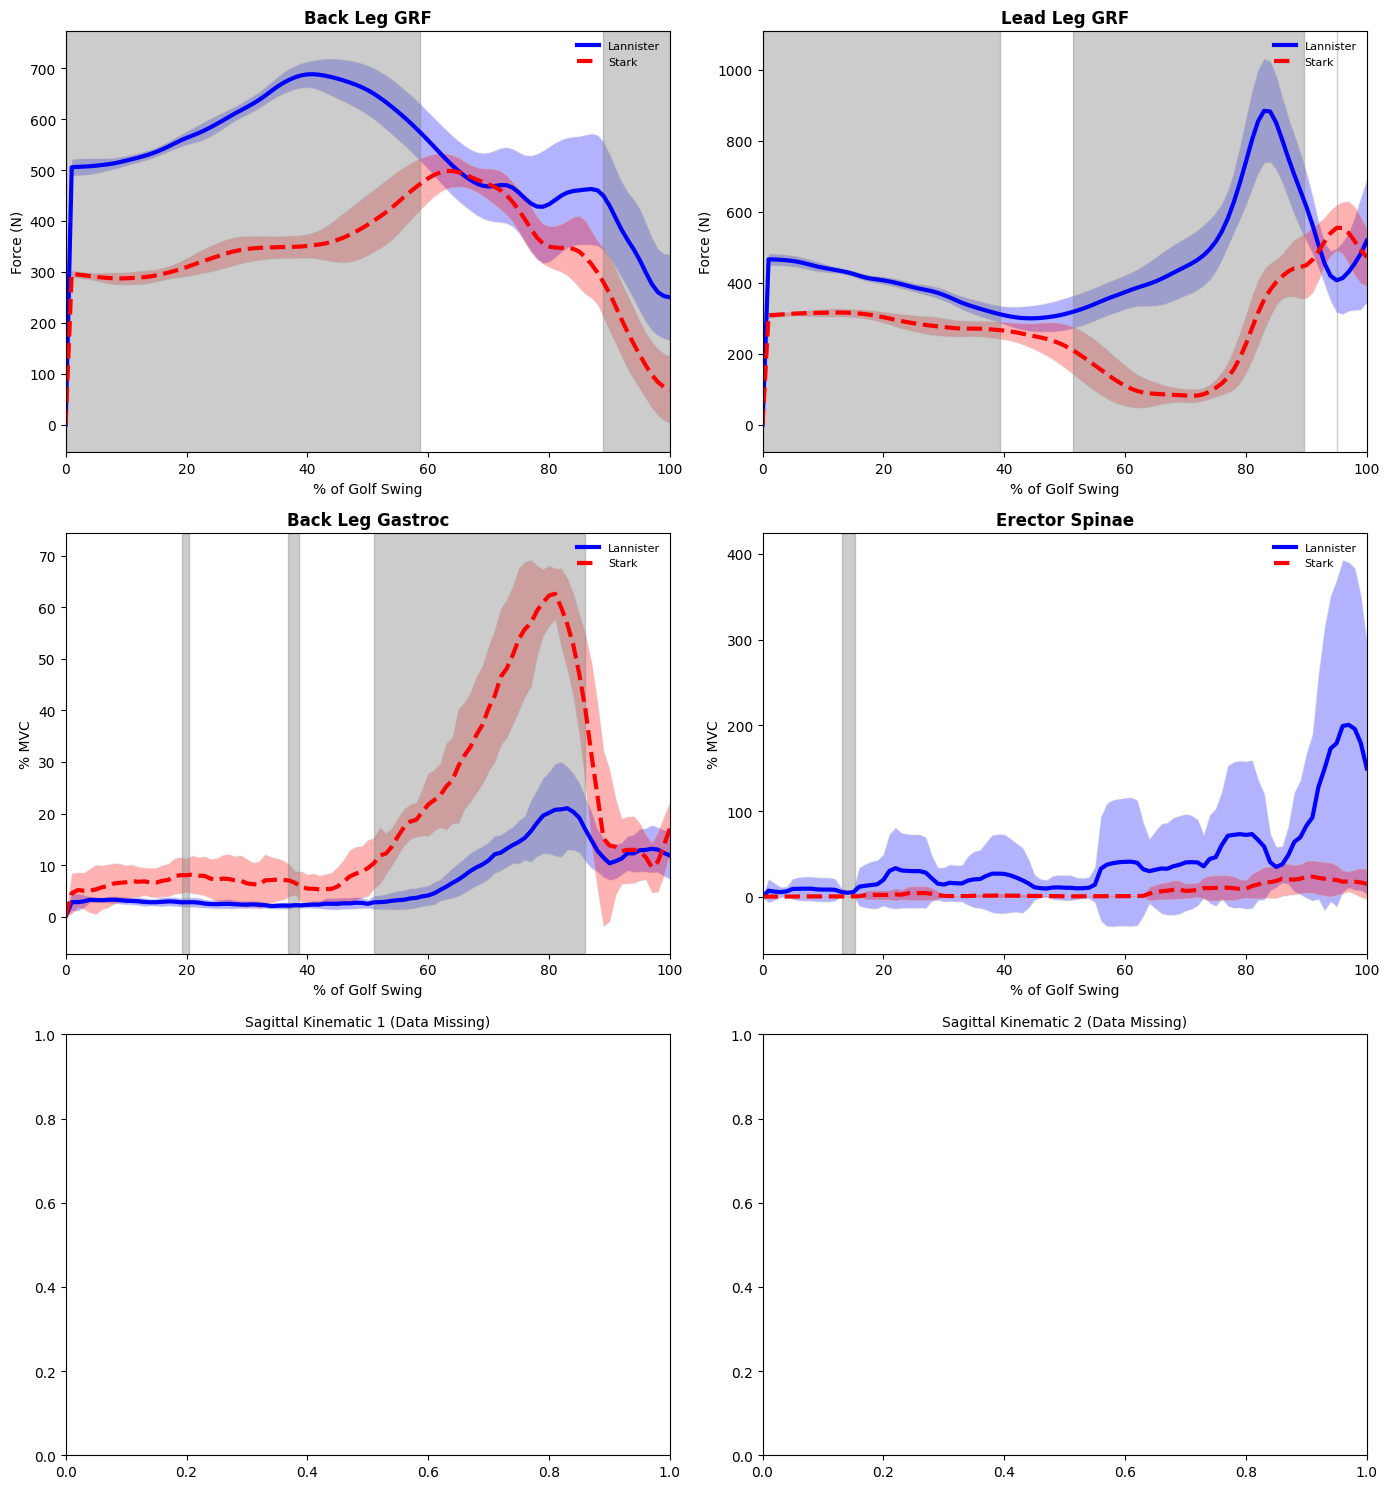

✅ Cell 4 Complete: 6-Panel SPM Figure Generated.


In [ ]:
# =============================================================================
# Cell 4: Generate the 6-Panel SPM Report
# =============================================================================
fig, axes = plt.subplots(3, 2, figsize=(14, 15))

# Adds a little breathing room between the graphs
plt.subplots_adjust(hspace=0.4)

# 1. Kinetics (Ground Reaction Forces)
plot_spm_comparison(axes[0, 0], spm_arrays['lannister']['Back_GRF'], spm_arrays['stark']['Back_GRF'], "Back Leg GRF", "Force (N)")
plot_spm_comparison(axes[0, 1], spm_arrays['lannister']['Lead_GRF'], spm_arrays['stark']['Lead_GRF'], "Lead Leg GRF", "Force (N)")

# 2. Electromyography (Muscle Activation)
plot_spm_comparison(axes[1, 0], spm_arrays['lannister']['Gastroc_EMG'], spm_arrays['stark']['Gastroc_EMG'], "Back Leg Gastroc", "% MVC")
plot_spm_comparison(axes[1, 1], spm_arrays['lannister']['Erector_EMG'], spm_arrays['stark']['Erector_EMG'], "Erector Spinae", "% MVC")

# 3. Kinematics (Joint/Segment Angles)
plot_spm_comparison(axes[2, 0], spm_arrays['lannister']['Kinematic_1'], spm_arrays['stark']['Kinematic_1'], "Sagittal Kinematic 1", "Angle (deg)")
plot_spm_comparison(axes[2, 1], spm_arrays['lannister']['Kinematic_2'], spm_arrays['stark']['Kinematic_2'], "Sagittal Kinematic 2", "Angle (deg)")

# Make it look clean
plt.tight_layout()
plt.show()

print("✅ Cell 4 Complete: 6-Panel SPM Figure Generated.")

In [ ]:
# =============================================================================
# Cell 5: Extract Discrete Metrics for Regression
# =============================================================================
import pandas as pd

# The exact columns the professor asked us to test
discrete_cols = [
    'CLUB_SPEED@Peak', 'X_Factor@Max', 'L5S1_Moment_Nm',
    'Back_GRFz', 'Lead_GRFz', 'R Gastroc_PERCENTMVC', 'ERECTOR_SPINAE_PERCENTMVC'
]

discrete_list = []
print("Extracting discrete peaks for the regression model...")

for file in all_files: # all_files was already defined in Cell 2
    df_raw = pd.read_csv(file, sep='\t', skiprows=1)
    df_raw.columns = df_raw.columns.str.strip()

    # Check which columns exist in this file
    valid_cols = [c for c in discrete_cols if c in df_raw.columns]

    if len(valid_cols) > 0:
        # In Visual3D, the single discrete peak values are stored on row index 3
        discrete_data = df_raw.loc[[3], valid_cols].copy()
        discrete_list.append(discrete_data)

# Combine all the swings into one clean Data Science table
df_discrete = pd.concat(discrete_list, ignore_index=True)
df_discrete = df_discrete.apply(pd.to_numeric, errors='coerce').dropna()

print(f"✅ Cell 5 Complete: Extracted discrete metrics for {len(df_discrete)} swings.")

# Display the first 5 rows to confirm it looks right
df_discrete.head()

Extracting discrete peaks for the regression model...
✅ Cell 5 Complete: Extracted discrete metrics for 20 swings.


,CLUB_SPEED@Peak,X_Factor@Max,L5S1_Moment_Nm,Back_GRFz,Lead_GRFz,R Gastroc_PERCENTMVC,ERECTOR_SPINAE_PERCENTMVC
0,33.83363,-29.16615,50.37854,496.85144,539.14453,69.32479,3.88167
1,43.32173,-39.14838,118.14111,722.95734,854.28345,26.62214,27.50977
2,30.71796,-39.65672,97.34325,649.59863,629.99384,17.07856,20.76841
3,45.41814,-39.16651,125.32932,724.83496,955.88196,27.12576,453.70697
4,32.40292,-15.84946,59.02083,532.04498,502.86615,70.63183,4.90659


In [ ]:
# =============================================================================
# Cell 6: Multiple Stepwise Regression Analysis
# =============================================================================
import statsmodels.formula.api as smf
import statsmodels.api as sm

# 1. Clean up column names (Statsmodels math breaks if there are spaces or @ symbols)
df_model = df_discrete.rename(columns={
    'CLUB_SPEED@Peak': 'Club_Speed',
    'X_Factor@Max': 'X_Factor',
    'L5S1_Moment_Nm': 'L5S1_Moment',
    'R Gastroc_PERCENTMVC': 'Gastroc',
    'ERECTOR_SPINAE_PERCENTMVC': 'Erector'
})

print("Running Forward Stepwise Selection algorithm...")

# 2. Define the Stepwise Algorithm
def forward_selected(data, response):
    remaining = set(data.columns)
    remaining.remove(response)
    selected = []
    current_score, best_new_score = 0.0, 0.0

    while remaining and current_score == best_new_score:
        scores_with_candidates = []
        for candidate in remaining:
            # Build the formula (e.g., Club_Speed ~ Lead_GRFz)
            formula = f"{response} ~ {' + '.join(selected + [candidate])} + 1"
            # Fit the model and get the R-squared score
            score = smf.ols(formula, data).fit().rsquared_adj
            scores_with_candidates.append((score, candidate))

        scores_with_candidates.sort()
        best_new_score, best_candidate = scores_with_candidates.pop()

        if current_score < best_new_score:
            remaining.remove(best_candidate)
            selected.append(best_candidate)
            current_score = best_new_score

    # Run the final, optimized model
    final_formula = f"{response} ~ {' + '.join(selected)} + 1"
    print(f"Optimal Formula Found: {final_formula}\n")
    model = smf.ols(final_formula, data).fit()
    return model

# 3. Execute the algorithm
final_model = forward_selected(df_model, 'Club_Speed')

print("✅ Cell 6 Complete: Regression Model Generated.\n")
print(final_model.summary())

Running Forward Stepwise Selection algorithm...
Optimal Formula Found: Club_Speed ~ Lead_GRFz + X_Factor + Erector + 1

✅ Cell 6 Complete: Regression Model Generated.

                            OLS Regression Results                            
Dep. Variable:             Club_Speed   R-squared:                       0.647
Model:                            OLS   Adj. R-squared:                  0.580
Method:                 Least Squares   F-statistic:                     9.762
Date:                Tue, 21 Apr 2026   Prob (F-statistic):           0.000671
Time:                        21:58:14   Log-Likelihood:                -58.550
No. Observations:                  20   AIC:                             125.1
Df Residuals:                      16   BIC:                             129.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          

Generating Statistical Assumption Plots...


/usr/local/lib/python3.12/dist-packages/statsmodels/graphics/gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


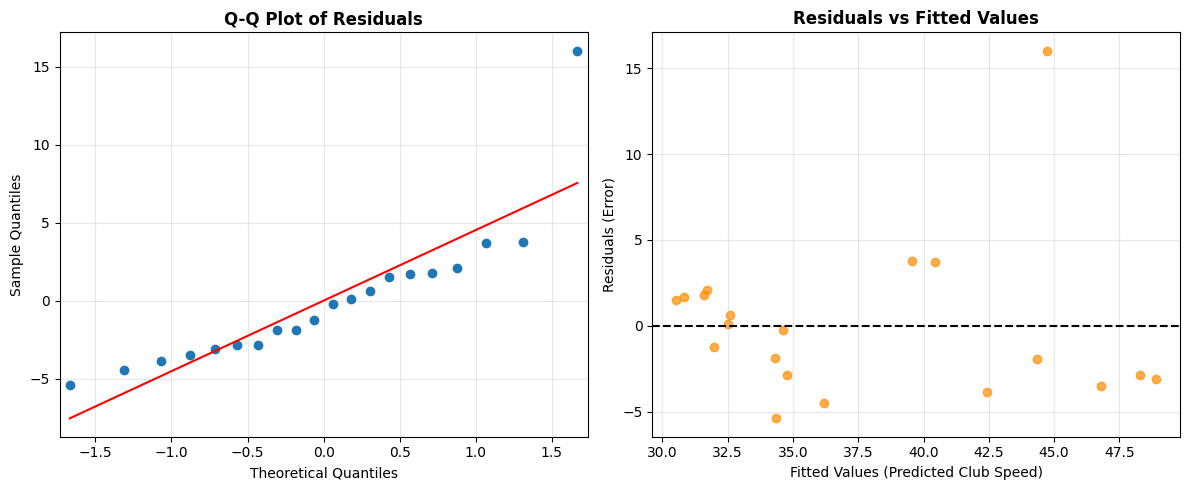

✅ Cell 7 Complete: Assumption checks plotted successfully.


In [ ]:
# =============================================================================
# Cell 7: Assumption Checks (Residuals & Q-Q Plots)
# =============================================================================
import matplotlib.pyplot as plt
import statsmodels.api as sm

print("Generating Statistical Assumption Plots...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Q-Q Plot (Checks if the errors/residuals are normally distributed)
# Note: 'final_model' was generated in Cell 6, so this will only work if Cell 6 ran properly.
sm.qqplot(final_model.resid, line='s', ax=axes[0], color='dodgerblue')
axes[0].set_title("Q-Q Plot of Residuals", fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 2. Residuals vs Fitted (Checks for homoscedasticity / even variance)
axes[1].scatter(final_model.fittedvalues, final_model.resid, alpha=0.7, color='darkorange')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel("Fitted Values (Predicted Club Speed)")
axes[1].set_ylabel("Residuals (Error)")
axes[1].set_title("Residuals vs Fitted Values", fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Cell 7 Complete: Assumption checks plotted successfully.")

In [ ]:
# =============================================================================
# Cell 8: Export Regression Results to CSV
# =============================================================================
import numpy as np
import pandas as pd

print("Extracting data and saving to CSV...")

# 1. Build the Model Summary Table
model_summary = pd.DataFrame({
    'Model': [1],
    'R': [np.sqrt(final_model.rsquared)],
    'R²': [final_model.rsquared],
    'Adjusted R²': [final_model.rsquared_adj],
    'F': [final_model.fvalue],
    'df1': [final_model.df_model],
    'df2': [final_model.df_resid],
    'p': [final_model.f_pvalue]
})

# 2. Build the Coefficients Table (The Predictors)
coef_table = pd.DataFrame({
    'Predictor': final_model.params.index,
    'B': final_model.params.values,
    'SE B': final_model.bse.values,
    't': final_model.tvalues.values,
    'p': final_model.pvalues.values,
    'CI Lower': final_model.conf_int()[0].values,
    'CI Upper': final_model.conf_int()[1].values
})

# 3. Clean up the 'Predictor' names so they look professional in the CSV
coef_table['Predictor'] = coef_table['Predictor'].replace({'Intercept': '(Intercept)'})

# 4. Save them as CSV files!
model_summary.to_csv('lab4_regression_model_summary.csv', index=False)
coef_table.to_csv('lab4_regression_table.csv', index=False)

print("✅ Cell 8 Complete: CSV files successfully generated!")
print("Look in the file browser on the left side of your Colab screen to download them.")

Extracting data and saving to CSV...
✅ Cell 8 Complete: CSV files successfully generated!
Look in the file browser on the left side of your Colab screen to download them.
